In [432]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

# # import  settings
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)

<module 'exp_pybamm_ver3' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/exp_pybamm_ver3.py'>

In [568]:
Rk = 1e-5
def OCV(opc_n,opc_p):
    return opc_p - opc_n

def exchange_current_dens(c,k=None,K = [5,2]):
    c_reduced = c[-1,...]/ np.max(c,axis = 0)
    F = sc.physical_constants['Faraday constant'][0]
    if k is None:
        K = 0.1 / F 
    elif k == 'n':
        K = K[0] / F 
        return  np.sqrt(c_reduced * (1-c_reduced)) 
    elif k == 'p':
        K = K[1] / F 
        return np.sqrt(c_reduced * (1-c_reduced)) 


def eta_r(i,cp,cn, params,K = [0.05,0.2]):
    Ln = params['Negative electrode thickness [m]']
    Lp = params['Positive electrode thickness [m]']
    
    A = params['Electrode width [m]'] * params['Electrode height [m]']
    T = params['Initial temperature [K]']
    
    R = sc.R
    F = sc.physical_constants['Faraday constant'][0]
    jp0 = exchange_current_dens(cp,k = 'p',K=K)
    jn0 = exchange_current_dens(cn,k = 'n',K=K)

    i_app = i / A
    jn = i_app / Ln
    jp = -i_app / Lp
    return 2 * R * T / F * (np.arcsinh(jn/jn0)-np.arcsinh(jp/(jp0)))

def V_terminal(I,cp,cn,ocp_p,ocp_n, params, K = [0.05,0.2]):
    U = OCV(ocp_n, ocp_p)
    eta = eta_r(I,cp,cn,params=params, K=K)
    return U - eta

In [561]:

sol, model,_,params = exp_pybamm_ver3.generate_data(model='SPM', RNG = False)
#sol, model,params = sim_PyBaMM.simulate(1)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
V_true = V = sol.observe(model.variables['Terminal voltage [V]'])(t)
I = sol.observe(model.variables['Current [A]'])(t)
ocp_p = sol.observe(model.variables['X-averaged positive electrode open-circuit potential [V]'])(t)
ocp_n = sol.observe(model.variables['X-averaged negative electrode open-circuit potential [V]'])(t)
cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)
cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)
c_max = sol.observe(model.variables['Maximum positive particle concentration [mol.m-3]'])(t)
# cn = sol.observe(model.variables['Negative particle surface concentration [mol.m-3]'])(t)
# cp = sol.observe(model.variables['Positive particle surface concentration [mol.m-3]'])(t)
jn0_true = sol.observe(model.variables['X-averaged negative electrode exchange current density [A.m-2]'])(t)
jp0_true = sol.observe(model.variables['X-averaged positive electrode exchange current density [A.m-2]'])(t)
OCV_true = sol.observe(model.variables['Surface open-circuit voltage [V]'])(t)

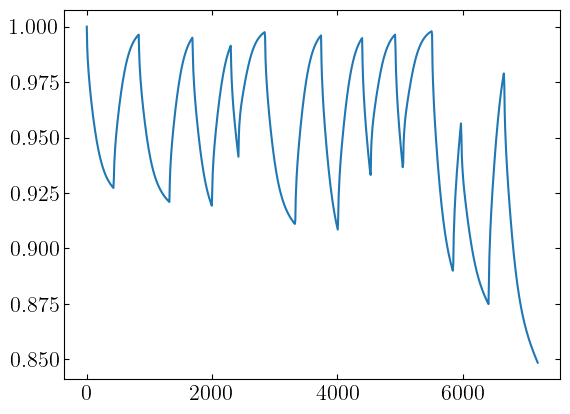

In [562]:
plt.plot(t,cn[-1,...]/ np.max(cn,axis = 0))

### Check OCV

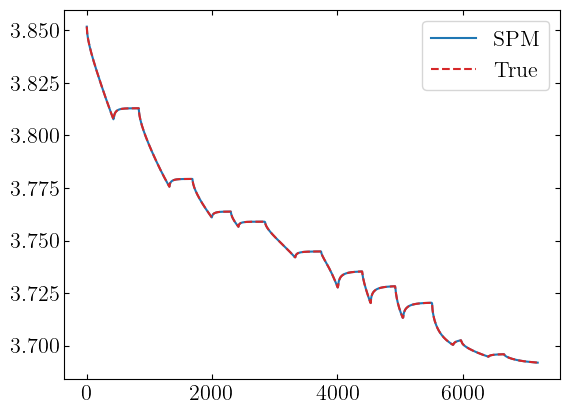

In [563]:
plt.plot(t, OCV(ocp_n,ocp_p),color = 'tab:blue', label = 'SPM')
plt.plot(t, OCV_true,color = 'tab:red',ls = '--', label = 'True')
plt.legend()

### Check $j_{k0}$

0.003526217426566522


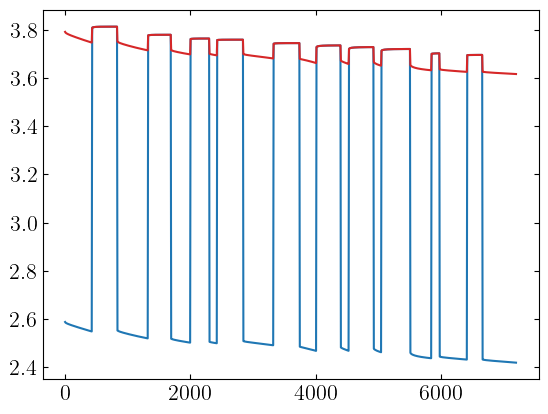

In [564]:
R = sc.R
F = sc.physical_constants['Faraday constant'][0]

Ln = params['Negative electrode thickness [m]']
Lp = params['Positive electrode thickness [m]']
    
A = params['Electrode width [m]'] * params['Electrode height [m]']
T = params['Initial temperature [K]']

i_app = I / A
jn = i_app / Ln
jp = -i_app / Lp

eta = 2 *  R * T / F * (np.arcsinh(jn/jn0_true)-np.arcsinh(jp/(jp0_true))) 

print(Lp/A)

plt.plot(t,OCV_true - eta,color = 'tab:blue', label = 'SPM')
plt.plot(t,V_true,color = 'tab:red', label = 'SPM')


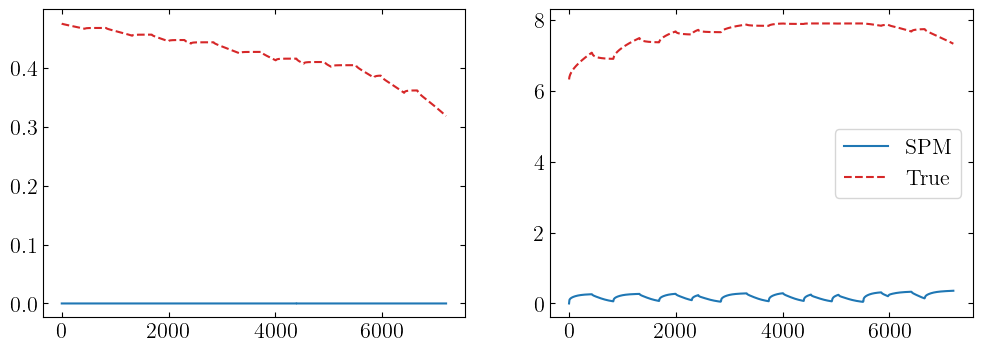

In [569]:
f, ax = plt.subplots(1,2,figsize = (12,4))

ax[0].plot(t, exchange_current_dens(cp,k = 'p'),color = 'tab:blue', label = 'SPM')
ax[0].plot(t, jp0_true,color = 'tab:red',ls = '--', label = 'True')
ax[1].plot(t, exchange_current_dens(cn,k = 'n'),color = 'tab:blue', label = 'SPM')
ax[1].plot(t, jn0_true,color = 'tab:red',ls = '--', label = 'True')
plt.legend()

### Check $\eta_r$

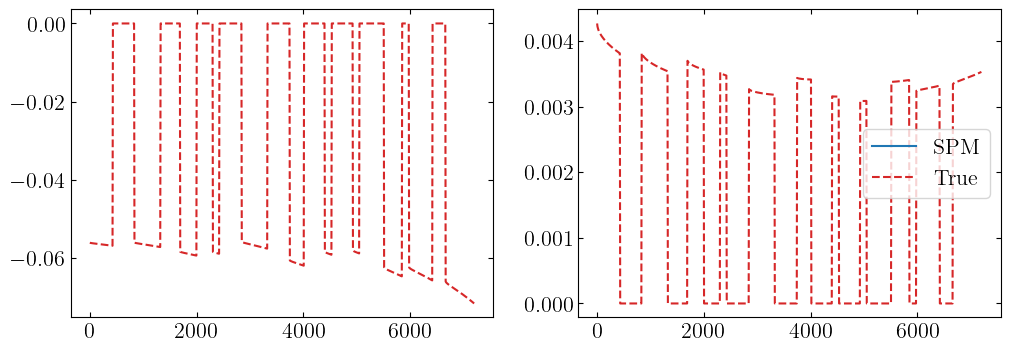

In [566]:
# eta_true_n = np.mean(sol.observe(model.variables['Negative electrode reaction overpotential [V]'])(t),axis =0)
# eta_true_p = np.mean(sol.observe(model.variables['Positive electrode reaction overpotential [V]'])(t),axis =0)
eta_true_n = sol.observe(model.variables['X-averaged battery negative reaction overpotential [V]'])(t)
eta_true_p = sol.observe(model.variables['X-averaged battery positive reaction overpotential [V]'])(t)


f, ax = plt.subplots(1,2,figsize = (12,4))
ax[0].plot(t, eta_r(I,cp,cn,params=params, K = [Kn,Kp]),color = 'tab:blue', label = 'SPM')
ax[0].plot(t, eta_true_p,color = 'tab:red',ls = '--', label = 'True')
ax[1].plot(t, eta_r(I,cp,cn,params=params, K = [Kn,Kp]),color = 'tab:blue', label = 'SPM')
ax[1].plot(t, eta_true_n,color = 'tab:red',ls = '--', label = 'True')
plt.legend()

In [567]:
Kp = 3e5
Kn = 1e8
V = V_terminal(I,cp,cn,ocp_p,ocp_n, params, K = None)
plt.plot(t, V,color = 'tab:blue', label = 'SPM')
plt.plot(t, V_true,color = 'tab:red',ls = '--', label = 'True')
plt.legend()    

TypeError: 'NoneType' object is not subscriptable